In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from pathlib import Path

In [2]:
# select the experiment for which you want to analyse data
experiment_id = "test_20260129_225813"

In [13]:
# set the paths
root_path = Path(globals()['_dh'][0]).parent
results_path = root_path / 'results' / experiment_id

# read the number of simulations from the config file
with open(results_path / 'config_used.yaml', "r") as f:
    config = yaml.safe_load(f)
n_sims = config['experiment']['n_simulations']

# read the results data for all simulations
iteration_histories = [pd.read_csv(results_path / 'data' / f'iteration_history_{sim+1}.csv')
                       for sim in range(n_sims)]

# combine multiple simulations into single dataframes
df_data_all = pd.concat(
    [df.assign(sim=i+1) for i, df in enumerate(iteration_histories)],
    ignore_index=True
)

df_transactions_all = df_data_all.loc[df_data_all['transaction_made']==True].reset_index()

In [14]:
df_data_all

,round,iteration,price,announcement_made,transaction_made,announcement_type,announcing_agent_id,announcing_agent_reservation_price,responding_agent_id,responding_agent_reservation_price,sim
0,1,1,2.0,True,True,buy,2.0,2.0,5,2.0,1
1,1,2,2.0,True,False,sell,4.0,1.5,0,1.0,1
2,1,2,2.0,True,False,sell,4.0,1.5,1,1.5,1
3,1,2,1.0,True,False,buy,0.0,1.0,3,1.0,1
4,1,2,1.0,True,False,buy,0.0,1.0,4,1.5,1
5,1,2,2.0,True,False,sell,3.0,1.0,0,1.0,1
6,1,2,2.0,True,False,sell,3.0,1.0,1,1.5,1
7,1,2,1.5,True,False,buy,1.0,1.5,3,1.0,1
8,1,2,1.5,True,True,buy,1.0,1.5,4,1.5,1
9,1,3,2.0,True,False,sell,3.0,1.0,0,1.0,1


### Plot Transaction Prices

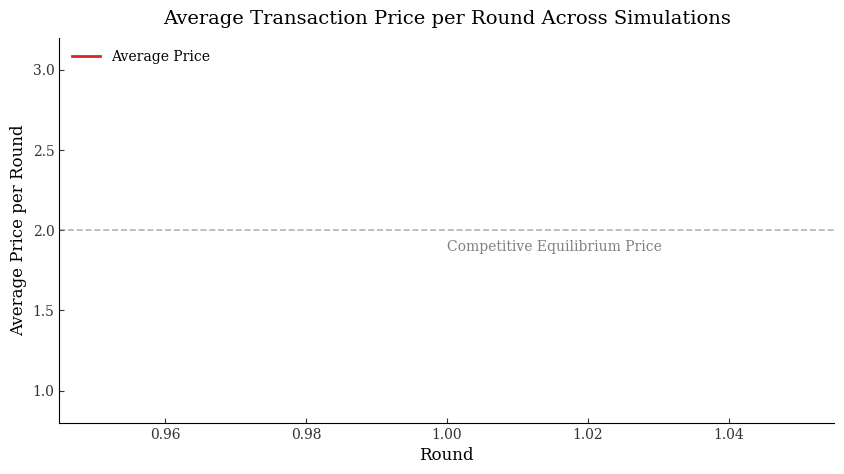

In [15]:
sim_round_avg = df_transactions_all.groupby(['sim', 'round'])['price'].agg(['mean', 'std', 'count']).reset_index()
df_plot = sim_round_avg.pivot_table(index='round', columns='sim', values='mean')
fig, ax = plt.subplots(figsize=(10,5))

# Colors
sim_color = '#1f77b4'  # semi-transparent for individual sims
avg_color = '#d62728'  # bold color for average

# Plot each simulation with light lines
for sim_id in df_plot.columns:
    ax.plot(
        df_plot.index,\
        df_plot[sim_id],
        color=sim_color,
        alpha=0.3,
        linewidth=1
    )

# Plot average across simulations
avg_prices = df_plot.mean(axis=1)
ax.plot(
    df_plot.index,
    avg_prices,
    color=avg_color,
    linewidth=2,
    label='Average Price'
)

# Equilibrium line
ax.axhline(y=2, color='grey', linestyle='--', linewidth=1.2, alpha=0.6)
ax.text(df_plot.index[0], 1.85, 'Competitive Equilibrium Price', color='grey', fontsize=10, family='serif', va='bottom')

# Labels and title
ax.set_xlabel('Round', fontsize=12, family='serif')
ax.set_ylabel('Average Price per Round', fontsize=12, family='serif')
ax.set_title('Average Transaction Price per Round Across Simulations',
             fontsize=14, family='serif', pad=10)

# Tick styling
ax.tick_params(axis='both', direction='in', labelsize=10, colors='#333333')
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_family('serif')

# Spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

# set the y-axis limit
ax.set_ylim(0.8, 3.2)

# Legend
ax.legend(loc='upper left', frameon=False, prop={'family': 'serif', 'size': 10})

# Disable grid
ax.grid(False)

# Layout and save
plt.show()
